In [1]:
!pwd

/users/khordadi/truejit/evaluation/compilation-plan


In [2]:
import os
import sys
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [3]:
benchmark = gcc_loops

In [4]:
generate_static_info(benchmark.binary)

In [5]:
static_info = get_static_info(benchmark.binary)
static_info

,id,name,size.bytecode,size.static
0,13,__wasm_call_ctors,6,808
1,14,_start,83,992
2,15,example1(),97,576
3,16,"example2a(int, int)",204,696
4,17,"example2b(int, int)",192,680
...,...,...,...,...
681,694,__nl_langinfo_l,441,1584
682,695,__strftime_fmt_1,1397,5976
683,696,week_num,241,1024
684,697,__strftime_l,792,1976


In [6]:
profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0].name) / 'profile.csv')
profile

,id,name,size.bytecode,size.static,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,exec.spec,compilation.spec,size.dynamic.spec
0,14,_start,83,992,58360,0,0,4669086,992,60380,0,0,0,4496135,992
1,13,__wasm_call_ctors,6,808,4728576,0,1,1815102,808,64910,0,1,0,1806322,808
2,142,_GLOBAL__I_000100,58,944,6544528,0,1,2388593,944,65480,0,1,0,2376467,944
3,117,std::__2::ios_base::Init::Init(),95,1008,8933851,0,1,2944023,1008,66370,0,1,0,2942428,1008
4,116,std::__2::DoIOSInit::DoIOSInit(),1418,4184,11880264,0,1,16727351,4184,68580,0,1,0,16642792,4184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,409,"std::__2::codecvt<wchar_t, char, __mbstate_t>:...",380,1368,6186755488,0,2,8541020,1368,1235854743221,0,2,0,7845693,1368
141,609,wcrtomb,312,856,6195298749,0,2,5464797,856,1235854745141,0,2,0,4976471,856
142,113,"std::__2::basic_ostream<wchar_t, std::__2::cha...",145,1168,6200767796,0,2,5025466,1168,1235854751341,0,2,0,4508199,1168
143,624,__stdio_exit,388,1712,6205797982,0,1,9301981,1712,1235854759731,0,1,0,8373063,1712


In [7]:
generate_profile_oracle(benchmark)
generate_profile_union(benchmark)
generate_plans(benchmark)

[workload] default
[binary_size] 2412587
[workload] default
[plan] min_e2e.unconstrained.default_static
[profile] trained_on_default
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.01 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:static]==> {'static': 673, 'specialize': 13}
[profile] oracle
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.01 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:static]==> {'static': 673, 'specialize': 13}
[profile] union
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.01 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:static]==> {'static': 673, 'specialize': 13}
[plan] min_e2e.unconstrained.default_jit
[profile] trained_on_default
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.01 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:jit]==> {'jit': 541, 'static': 132, 'specialize': 13}
[profile] oracle
[goal] EndToEndTime
Solving...
[status] Optima

In [8]:
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e.unconstrained.default_static') / 'oracle.json')
df = pd.merge(profile, plan, on='id', how='outer')
df

,id,name,size.bytecode,size.static,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,exec.spec,compilation.spec,size.dynamic.spec,mode
0,13,__wasm_call_ctors,6.0,808.0,4.728576e+06,0.0,1.0,1815102.0,808.0,6.491000e+04,0.000000e+00,1.0,0.0,1806322.0,808.0,static
1,14,_start,83.0,992.0,5.836000e+04,0.0,0.0,4669086.0,992.0,6.038000e+04,0.000000e+00,0.0,0.0,4496135.0,992.0,static
2,15,example1(),97.0,576.0,5.958880e+08,220000000.0,2621441.0,3582314.0,576.0,8.021589e+06,8.409000e+10,2621441.0,215000000.0,3556814.0,576.0,specialize
3,16,"example2a(int, int)",204.0,696.0,8.289911e+08,240000000.0,1048577.0,6080787.0,696.0,8.485667e+10,4.644000e+10,1048577.0,55000000.0,3576373.0,760.0,specialize
4,17,"example2b(int, int)",192.0,680.0,1.100748e+09,390000000.0,524289.0,5028767.0,680.0,1.317176e+11,8.185000e+10,524289.0,150000000.0,3506504.0,576.0,specialize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
682,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
683,696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
684,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static


In [ ]:
plans = []
plans_names = ['Interpreter', 'JIT', 'AOT', 'Code = 0', r'Code $< 10\,\mathrm{KB}$', r'Code $< 200\,\mathrm{KB}$', 'Unbounded Code']
plans.append(Planner(None, None, 'interpret'))
plans.append(Planner(None, None, 'jit'))
plans.append(Planner(None, None, 'static'))
plans.append(Planner(EndToEndTime(),
                       [Constraint(StaticCodeSize(), upper_bound=0), Constraint(DynamicCodeSize(), upper_bound=0)],
                       'interpret'))
plans.append(Planner(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=10_000),
                                        Constraint(DynamicCodeSize(), upper_bound=10_000)
                                        ], 'interpret'))

plans.append(Planner(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=100_000),
                                        Constraint(DynamicCodeSize(), upper_bound=100_000)], 'interpret'))

plans.append(Planner(EndToEndTime(), [], 'static'))

history = get

evaluations = []
for plan in plans:
    plan = plan.plan(static_info, profile)
    evaluation = PlanEvaluation(static_info, profile, plan, history)
    evaluations.append(evaluation)

[plan evaluation] merged static_info | base_profile: 686 rows
[plan evaluation] merged static_info | base_profile | plan: 686 rows
[plan evaluation] merged static_info | base_profile: 686 rows
[plan evaluation] merged static_info | base_profile | plan: 686 rows
[plan evaluation] merged static_info | base_profile: 686 rows
[plan evaluation] merged static_info | base_profile | plan: 686 rows
[goal] EndToEndTime
[constraint] StaticCodeSize <= 0
[constraint] DynamicCodeSize <= 0
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[plan evaluation] merged static_info | base_profile: 686 rows
[plan evaluation] merged static_info | base_profile | plan: 686 rows
[goal] EndToEndTime
[constraint] StaticCodeSize <= 10000
[constraint] DynamicCodeSize <= 20000
Solving...
[status] Optimal
[elapsed time] 0.11 seconds
[plan evaluation] merged static_info | base_profile: 686 rows
[plan evaluation] merged static_info | base_profile | plan: 686 rows
[goal] EndToEndTime
[constraint] StaticCodeSize <= 

In [28]:
# Wong colorblind-friendly palette (prints well in grayscale)
INTERPRETER_COLOR  = '#D55E00'  # Vermillion
JIT_COLOR     = '#56B4E9'  # Sky Blue
AOT_COLOR  = '#009E73'  # Bluish Green
CAPER_COLOR   = '#CC79A7'  # Reddish Purple

colors = [INTERPRETER_COLOR, JIT_COLOR, AOT_COLOR]
for i in range(len(plans[3:])):
    colors.append(CAPER_COLOR)

In [29]:
code_sizes = [e.static_code_size + e.dynamic_code_size for e in evaluations]
e2es = [e.e2e for e in evaluations]

In [30]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

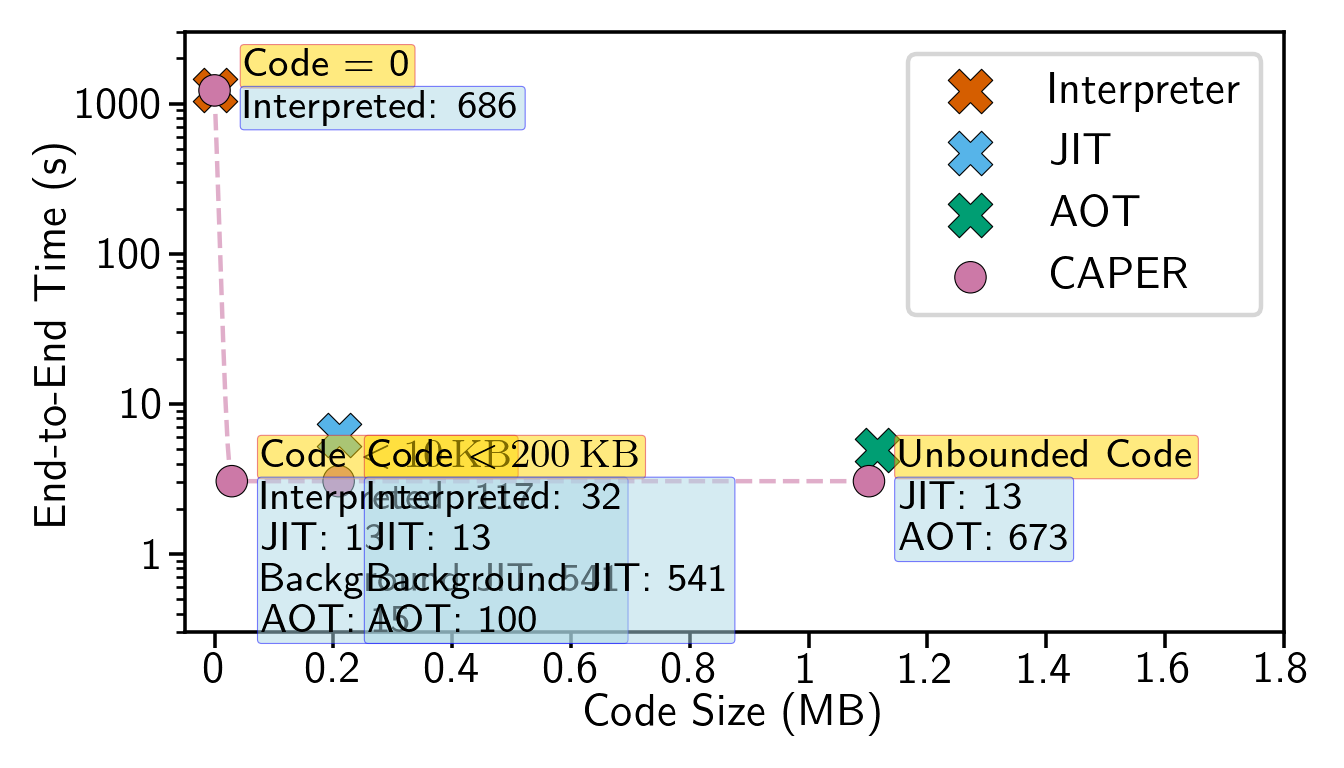

In [31]:
fig, ax = plt.subplots(figsize=(4, 2.2), dpi=320)

linewidth = 0.25
ax.scatter(code_sizes[0], e2es[0], color=colors[0], label=plans_names[0], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[1], e2es[1], color=colors[1], label=plans_names[1], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[2], e2es[2], color=colors[2], label=plans_names[2], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)

ax.scatter(code_sizes[3:], e2es[3:], color=colors[3:], label='CAPER', alpha=1, edgecolor='black', linewidth=linewidth,
           marker='o', s=50)

from scipy.interpolate import PchipInterpolator
_caper_xs = np.array(code_sizes[3:], dtype=float)
_caper_ys = np.array(e2es[3:], dtype=float)
_sort_idx = np.argsort(_caper_xs)
_caper_xs = _caper_xs[_sort_idx]
_caper_ys = _caper_ys[_sort_idx]
_pchip = PchipInterpolator(_caper_xs, np.log10(_caper_ys))
_x_curve = np.linspace(_caper_xs[0], _caper_xs[-1], 300)
_y_curve = 10 ** _pchip(_x_curve)
ax.plot(_x_curve, _y_curve, color=CAPER_COLOR, linewidth=1.0, linestyle='--', alpha=0.6, zorder=0)

LEFT_PADDING = 50000
for i in range(len(plans[3:])):
    eval = evaluations[3 + i]
    text = plans_names[3 + i]
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1.9, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='gold', edgecolor='crimson', alpha=0.5, linewidth=linewidth, boxstyle='round,pad=0.1'))
    text = ''
    if eval.interpret:
        text += f'Interpreted: {eval.interpret}\n'
    if eval.jit:
        text += f'JIT: {eval.jit}\n'
    if eval.specialize:
        text += f'JIT: {eval.specialize}\n'
    if eval.async_compilation:
        text += f'Background JIT: {eval.async_compilation}\n'
    if eval.static:
        text += f'AOT: {eval.static}\n'
    text = text.strip()
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='lightblue', edgecolor='blue', alpha=0.5, linewidth=linewidth, boxstyle='round,pad=0.1'))

# make y log
ax.set_ylim(3e8, 3e12)
ax.set_yscale('log')
ax.set_yticks([1e9, 1e10, 1e11, 1e12])
ax.set_yticklabels(['1', '10', '100', '1000'])

# set x lim to 1.5MB
ax.set_xlim(-50000, 180000)
# 0, 200k, 400k, 600k, ..., 1MB
ax.set_xticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000, 1400000, 1600000, 1800000])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1', '1.2', '1.4', '1.6', '1.8'])

ax.tick_params(axis='both', pad=1)

ax.set_xlabel('Code Size (MB)', labelpad=0)
ax.set_ylabel('End-to-End Time (s)', labelpad=0)
# ax.set_title(f'{benchmark.name} Compilation Plans Comparison')
ax.legend()

# make it tight
plt.tight_layout(pad=0)

# to pdf
plt.savefig(f'out/pareto-curve.pdf', bbox_inches='tight', dpi=320, format='pdf', transparent=True, pad_inches=0)

plt.show()

In [32]:
plans_fns = []
for i, planning in enumerate(plans[3:][::-1]):
    # print(plan_title)
    plan = planning.plan(static_info, profile)
    plans_fns.append((plans_names[3 + i], plan['mode'].tolist()))

[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[goal] EndToEndTime
[constraint] StaticCodeSize <= 100000
[constraint] DynamicCodeSize <= 200000
Solving...
[status] Optimal
[elapsed time] 0.08 seconds
[goal] EndToEndTime
[constraint] StaticCodeSize <= 10000
[constraint] DynamicCodeSize <= 20000
Solving...
[status] Optimal
[elapsed time] 0.05 seconds
[goal] EndToEndTime
[constraint] StaticCodeSize <= 0
[constraint] DynamicCodeSize <= 0
Solving...
[status] Optimal
[elapsed time] 0.01 seconds


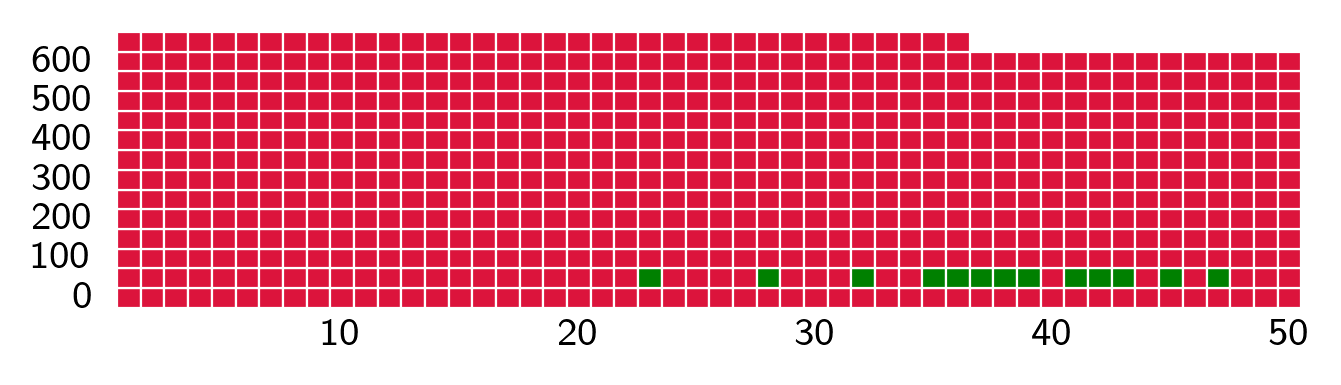

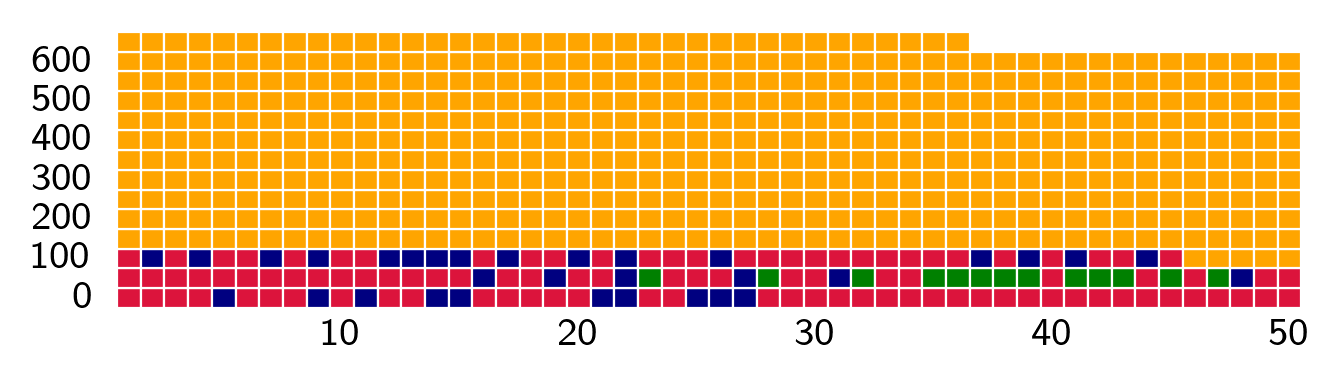

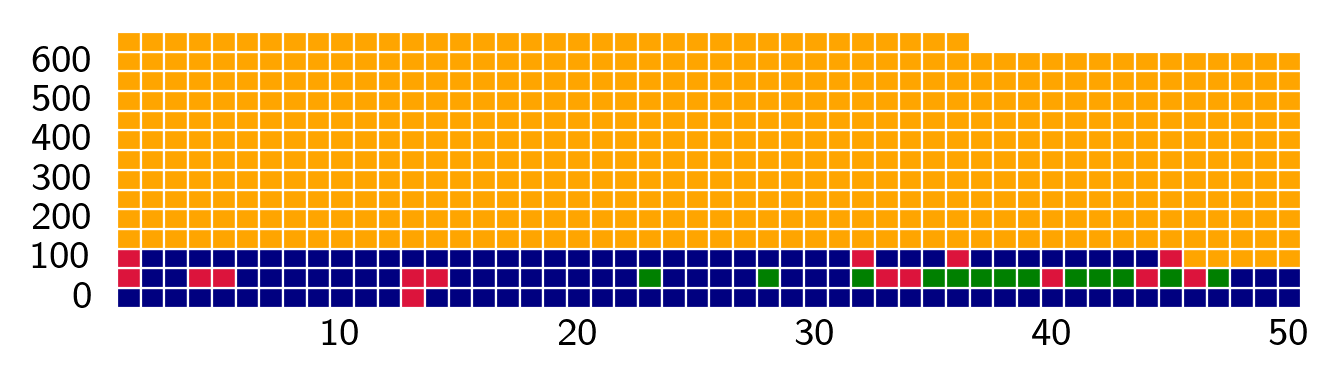

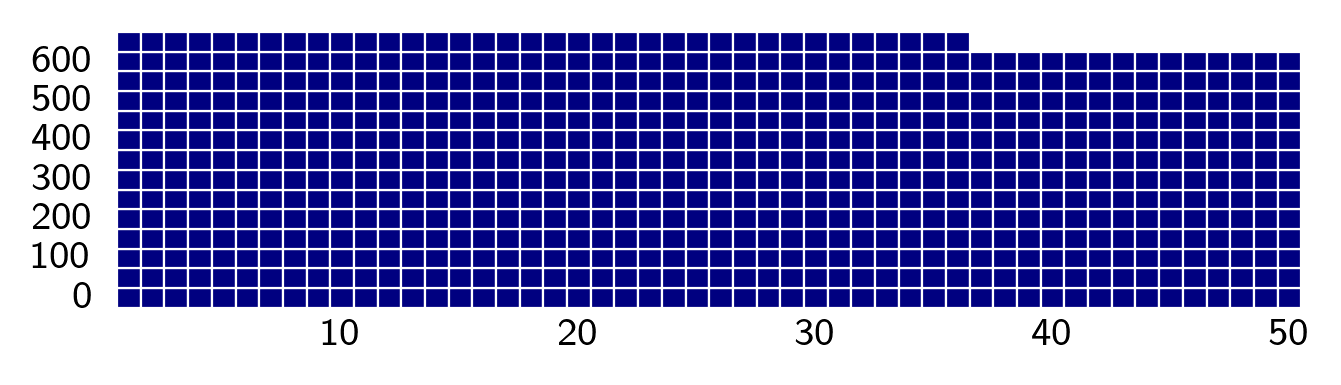

In [33]:
import matplotlib.pyplot as plt



def get_fn_color(mode):
    if mode == 'interpret':
        return 'navy'
    elif mode == 'jit':
        return JIT_COLOR
    elif mode == 'static':
        return 'crimson'
    elif mode == 'async':
        return 'orange'
    elif mode == 'specialize':
        # greenish color
        return 'green'
    else:
        return CAPER_COLOR

columns = 50

width = 1
height = 1


# fig, axs = plt.subplots(len(plans_fns), 1, figsize=(4, len(plans_fns) * .5), dpi=320, sharex=True)

cnt = 0
for plan_title, fns in plans_fns:
    fig, ax = plt.subplots(figsize=(4, 1), dpi=320, sharex=True)

    for i, fn_mode in enumerate(fns):
        x = (i%columns) * (width)
        y = i // columns * (height)
        ax.add_patch(plt.Rectangle((x, y), width, height, linewidth=.5, edgecolor='white', facecolor=get_fn_color(fn_mode)))

    # write the 0, 100, 200, ... labels on the left of the plot
    for i in range(0, len(fns), 100):
        ax.text(-width, (i // columns) * height + height/2, str(i), fontsize=9, ha='right', va='center')


    ax.set_xlim(-width, columns * width)
    ax.set_ylim(0, ((len(fns) - 1) // columns + 1) * height)

    # ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # write the plan title on the top middle of the plot
    # ax.set_title(plan_title, fontsize=4, pad=1)

    # write 20, 40, 60, 80 labels on the top of the plot
    for i in range(10, columns+1, 10):
        ax.text((i-1) * width + width/2, -height+height/2, str(i), fontsize=9, ha='center', va='top')


    # tight layout
    plt.tight_layout(pad=0)

    # to pdf
    plt.savefig(f'out/plans.{cnt}.pdf', bbox_inches='tight', dpi=320, format='pdf', pad_inches=0, transparent=True)

    plt.show()
    cnt += 1